<a href="https://colab.research.google.com/github/priya5032007/solarpower-system/blob/main/datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Q01_solar_farm.csv')

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('Q01_solar_farm.csv')

# Option 1: Impute missing values using column medians/means
df['ambient_temperature_c'] = df['ambient_temperature_c'].fillna(df['ambient_temperature_c'].median())
df['sunlight_duration_hours'] = df['sunlight_duration_hours'].fillna(df['sunlight_duration_hours'].median())

# Option 2 (Alternative): Simply drop rows with any missing values
# df = df.dropna().reset_index(drop=True)

# Save the cleaned file
df.to_csv('cleaned_solar_farm.csv', index=False)
print("Missing values handled successfully!")

Missing values handled successfully!


--- RAW DATA OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   record_id                123 non-null    object 
 1   timestamp                123 non-null    object 
 2   farm                     123 non-null    object 
 3   panel_capacity_kw        123 non-null    int64  
 4   panel_output_kwh         123 non-null    float64
 5   ambient_temperature_c    122 non-null    float64
 6   sunlight_duration_hours  121 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 6.9+ KB
None

--- SUMMARY STATISTICS ---
                        timestamp  panel_capacity_kw  panel_output_kwh  \
count                         120         120.000000        120.000000   
mean   2026-04-14 15:43:04.500000         135.916667         85.016333   
min           2026-01-02 09:16:00         100.000000         29.630

/tmp/ipykernel_1316/2054281677.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='farm', y='panel_efficiency_pct', palette='Set2', ax=axes[1])


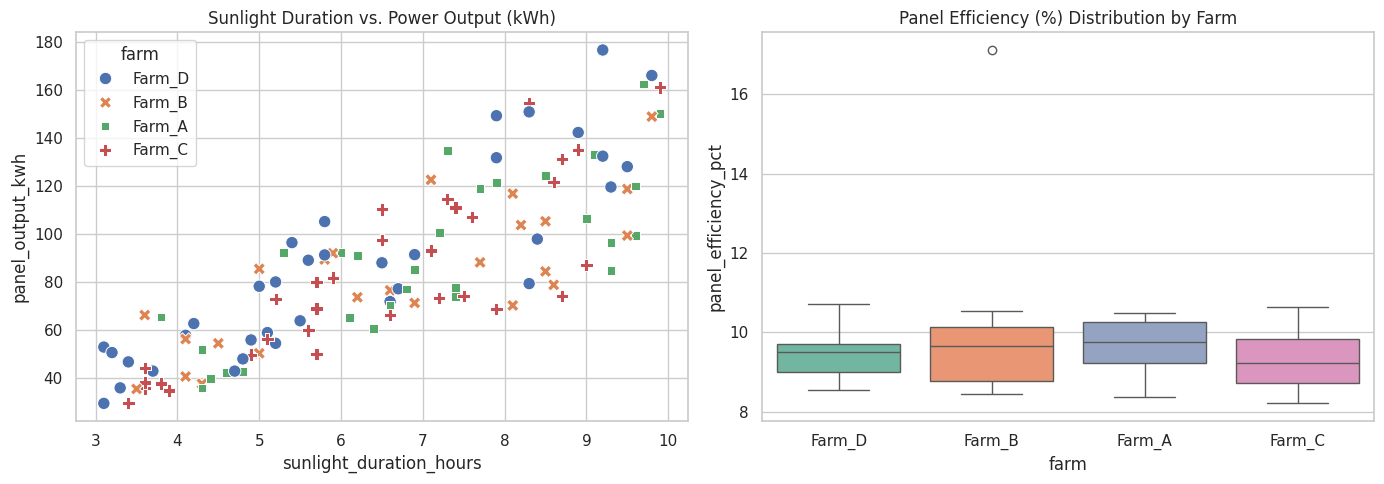


--- STATISTICAL ANALYSIS ---
Pearson Correlation (Sunlight vs Output): r = 0.8258, p-value = 3.9498e-31
One-Way ANOVA (Efficiency across Farms): F-Statistic = 2.2130, p-value = 0.0903

Cleaned dataset saved as 'cleaned_solar_farm.csv'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual styling
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASET
# ==========================================
df = pd.read_csv('Q01_solar_farm.csv')
print("--- RAW DATA OVERVIEW ---")
print(df.info())

# ==========================================
# 2. DATA CLEANING & MISSING VALUES
# ==========================================
# Parse timestamp strings into datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Clean string formatting
df['farm'] = df['farm'].str.strip()

# Impute missing 'ambient_temperature_c' with median
median_temp = df['ambient_temperature_c'].median()
df['ambient_temperature_c'] = df['ambient_temperature_c'].fillna(median_temp)

# Impute missing 'sunlight_duration_hours' using panel_capacity_kw group medians
df['sunlight_duration_hours'] = df.groupby('panel_capacity_kw')['sunlight_duration_hours'].transform(
    lambda x: x.fillna(x.median())
)

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
# Calculate Panel Efficiency Percentage (%)
# Formula: (Output kWH) / (Capacity kW * Sunlight Hours) * 100
df['panel_efficiency_pct'] = (
    df['panel_output_kwh'] / (df['panel_capacity_kw'] * df['sunlight_duration_hours'])
) * 100

# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

print("\n--- MEAN METRICS BY FARM ---")
print(df.groupby('farm')[['panel_output_kwh', 'panel_efficiency_pct', 'sunlight_duration_hours']].mean())

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Sunlight vs Power Output
sns.scatterplot(
    data=df, x='sunlight_duration_hours', y='panel_output_kwh',
    hue='farm', style='farm', s=80, ax=axes[0]
)
axes[0].set_title('Sunlight Duration vs. Power Output (kWh)')

# Plot B: Efficiency Distribution across Farms
sns.boxplot(data=df, x='farm', y='panel_efficiency_pct', palette='Set2', ax=axes[1])
axes[1].set_title('Panel Efficiency (%) Distribution by Farm')

plt.tight_layout()
plt.show()

# ==========================================
# 5. STATISTICAL ANALYSIS (Pearson & ANOVA)
# ==========================================
print("\n--- STATISTICAL ANALYSIS ---")

# Method A: Pearson Correlation between Sunlight Duration and Output
corr, p_val_corr = stats.pearsonr(df['sunlight_duration_hours'], df['panel_output_kwh'])
print(f"Pearson Correlation (Sunlight vs Output): r = {corr:.4f}, p-value = {p_val_corr:.4e}")

# Method B: One-Way ANOVA (Test efficiency difference across farms)
farm_groups = [group['panel_efficiency_pct'].values for name, group in df.groupby('farm')]
f_stat, p_val_anova = stats.f_oneway(*farm_groups)
print(f"One-Way ANOVA (Efficiency across Farms): F-Statistic = {f_stat:.4f}, p-value = {p_val_anova:.4f}")

# Save cleaned output
df.to_csv('cleaned_solar_farm.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_solar_farm.csv'.")

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Q01_solar_farm.csv')

# Preview initial structure
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (123, 7)


,record_id,timestamp,farm,panel_capacity_kw,panel_output_kwh,ambient_temperature_c,sunlight_duration_hours
0,SOL0001,2026-03-27 03:39,Farm_D,150,128.04,22.0,9.5
1,SOL0002,2026-04-25 07:13,Farm_B,100,50.47,32.3,5.0
2,SOL0003,2026-06-03 16:42,Farm_A,120,52.05,30.4,4.3
3,SOL0004,2026-03-20 21:39,Farm_B,120,54.61,29.4,4.5
4,SOL0005,2026-07-20 15:54,Farm_D,100,79.42,29.8,8.3


In [ ]:
# Convert timestamp strings to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Remove exact duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# Trim leading/trailing whitespace from string columns
df['farm'] = df['farm'].str.strip()

print("Preprocessing complete. Duplicate count:", df.duplicated().sum())

Preprocessing complete. Duplicate count: 0


In [ ]:
# Check missing values before imputation
print("Missing values before:\n", df.isnull().sum())

# Impute temperature missing values using column median
median_temp = df['ambient_temperature_c'].median()
df['ambient_temperature_c'] = df['ambient_temperature_c'].fillna(median_temp)

# Impute sunlight duration missing values using group medians (grouped by panel capacity)
df['sunlight_duration_hours'] = df.groupby('panel_capacity_kw')['sunlight_duration_hours'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after:\n", df.isnull().sum())

Missing values before:
 record_id                  0
timestamp                  0
farm                       0
panel_capacity_kw          0
panel_output_kwh           0
ambient_temperature_c      1
sunlight_duration_hours    2
dtype: int64

Missing values after:
 record_id                  0
timestamp                  0
farm                       0
panel_capacity_kw          0
panel_output_kwh           0
ambient_temperature_c      0
sunlight_duration_hours    0
dtype: int64


In [ ]:
# Calculate Panel Efficiency (%) = Output / (Capacity * Sunlight Duration) * 100
df['panel_efficiency_pct'] = (
    df['panel_output_kwh'] / (df['panel_capacity_kw'] * df['sunlight_duration_hours'])
) * 100

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

df[['timestamp', 'panel_capacity_kw', 'sunlight_duration_hours', 'panel_output_kwh', 'panel_efficiency_pct']].head()

,timestamp,panel_capacity_kw,sunlight_duration_hours,panel_output_kwh,panel_efficiency_pct
0,2026-03-27 03:39:00,150,9.5,128.04,8.985263
1,2026-04-25 07:13:00,100,5.0,50.47,10.094000
2,2026-06-03 16:42:00,120,4.3,52.05,10.087209
3,2026-03-20 21:39:00,120,4.5,54.61,10.112963
4,2026-07-20 15:54:00,100,8.3,79.42,9.568675


--- SUMMARY STATISTICS ---
                        timestamp  panel_capacity_kw  panel_output_kwh  \
count                         120         120.000000        120.000000   
mean   2026-04-14 15:43:04.500000         135.916667         85.016333   
min           2026-01-02 09:16:00         100.000000         29.630000   
25%           2026-02-23 06:53:30         100.000000         56.347500   
50%           2026-04-07 16:48:30         120.000000         79.760000   
75%           2026-06-08 11:26:30         157.500000        106.680000   
max           2026-07-30 22:32:00         180.000000        176.530000   
std                           NaN          30.801501         34.971580   

       ambient_temperature_c  sunlight_duration_hours  panel_efficiency_pct  \
count             120.000000               120.000000            120.000000   
mean               31.079167                 6.517500              9.520901   
min                16.600000                 3.100000              8.

/tmp/ipykernel_1316/2674103515.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='farm', y='panel_efficiency_pct', palette='Set2', ax=axes[1])


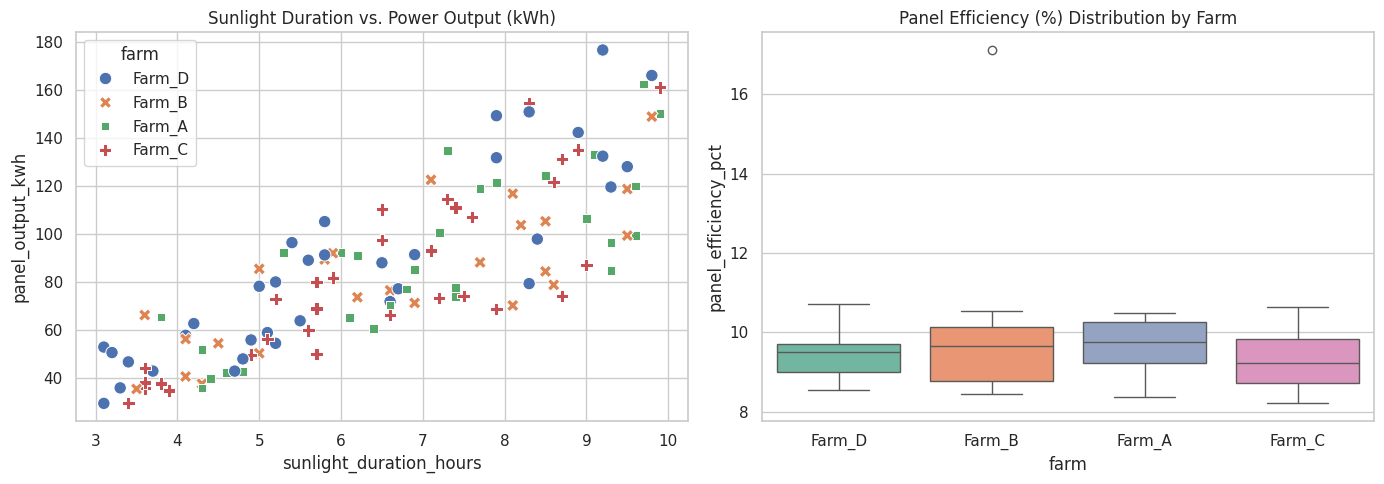

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Descriptive statistics
print("--- SUMMARY STATISTICS ---")
print(df.describe())

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Sunlight vs Power Output
sns.scatterplot(
    data=df, x='sunlight_duration_hours', y='panel_output_kwh',
    hue='farm', style='farm', s=80, ax=axes[0]
)
axes[0].set_title('Sunlight Duration vs. Power Output (kWh)')

# Plot B: Efficiency Distribution across Farms
sns.boxplot(data=df, x='farm', y='panel_efficiency_pct', palette='Set2', ax=axes[1])
axes[1].set_title('Panel Efficiency (%) Distribution by Farm')

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Pearson Correlation: Sunlight Duration vs Output
corr, p_val_corr = stats.pearsonr(df['sunlight_duration_hours'], df['panel_output_kwh'])
print(f"Pearson Correlation (Sunlight vs Output): r = {corr:.4f}, p-value = {p_val_corr:.4e}")

# One-Way ANOVA: Compare Efficiency across Farms
farm_groups = [group['panel_efficiency_pct'].values for name, group in df.groupby('farm')]
f_stat, p_val_anova = stats.f_oneway(*farm_groups)
print(f"One-Way ANOVA (Efficiency across Farms): F = {f_stat:.4f}, p-value = {p_val_anova:.4f}")

# Save the final cleaned data
df.to_csv('cleaned_solar_farm.csv', index=False)
print("\nDataset successfully exported to 'cleaned_solar_farm.csv'")


Pearson Correlation (Sunlight vs Output): r = 0.8258, p-value = 3.9498e-31
One-Way ANOVA (Efficiency across Farms): F = 2.2130, p-value = 0.0903

Dataset successfully exported to 'cleaned_solar_farm.csv'


In [ ]:
# Save cleaned dataset
df.to_csv('cleaned_solar_farm.csv', index=False)

# Download the file
from google.colab import files
files.download('cleaned_solar_farm.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>